# Ground Condition Predictor — 1D-CNN (raw-window sequence model) — **merged** (grass / loose / paved)

Combines the accumulated pipeline's features with the ground-up shape / pressure-distribution / spatial-dynamics features (prefixed `gu_`), and **drops the person-confound features** (per-sensor `*_mean_ratio` and raw magnitudes `total_p_mean`/`impact_mag`/`total_pmax`) that hurt cross-user generalisation. Same analyses, dashboard, distributions, prediction and 1D-CNN format.

Flip `CV_GROUP` (Section 3) between `source_recording` and `source_user`. After running, check the dashboard's feature-importance panel and prune anything with ~0 cross-user value — more features is not automatically better here.

> **1D-CNN variant — evaluation-matched, not process-identical.**
>
> This model is a **1D temporal CNN on raw step windows** (z-scored per channel), *not* a feature-based classifier. It is evaluated under the **same protocol** as the SVM/k-NN/XGBoost notebooks — same recordings, same quality gate, same step gate, same grouped (leave-user-out) StratifiedGroupKFold CV, and the same macro-F1 / per-class / confusion-matrix reporting — so its numbers sit in the same comparison table.
>
> **What is intentionally absent, and why:** the per-classifier *feature* analyses in the other notebooks (sequential forward selection, permutation feature importance, standard-vs-tailored feature preprocessing) **do not apply** here. The CNN consumes raw time-series windows and learns its own representation; there are no 48 engineered features to select from, rank, or rescale. Forcing those analyses onto it would fabricate results that mean nothing. The CNN's own preprocessing (resample to fixed length + per-channel z-scoring) is shown in the window builder below. Requires PyTorch (`pip install torch`); uses the GPU if available.

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os, glob, shutil

# ── Sensor groups ─────────────────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'dirt': 'loose', 'compact ground': 'loose', 'compacted ground': 'loose',
    'concrete': 'paved', 'asphalt': 'paved', 'exposed aggregate': 'paved', 'brick': 'paved'
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1,13)]
)
SURFACE_COLORS = {'paved':'#607D8B','grass':'#4CAF50','loose':'#8D6E63','unknown':'#9E9E9E'}

# ── Composite score weights ───────────────────────────────────────────
# Rewards balanced performance across all classes, with extra weight on
# Texture/frequency features (help separate rigid paved surfaces)
W_ACC=0.30; W_MACRO_F1=0.50; W_FOCUS_F1=0.20
FOCUS_CLASS = 'loose'   # composite up-weights this (likely the minority)

# ── Merged model: drop person-confound features (per-sensor ratios + raw magnitudes) ──
# These inflate in-sample importance but hurt cross-user generalisation (proven by
# cross-user permutation importance). Kept out of the feature matrix, not the extractor.
DROP_FEATURES = ['total_p_mean','impact_mag','total_pmax','impact_mag_norm',
                 'heel_mean_ratio','fore_mean_ratio','heel_pmax_ratio','fore_pmax_ratio',
                 'heel_impulse'] + [f'pressure_{i:02d}_mean_ratio' for i in range(1,13)]

# ── Full-step filter: exclude steps whose window spans a surface transition ──
EXCLUDE_TRANSITION_STEPS    = True
TRANSITION_MIN_LABELED_FRAC = 0.80   # a kept step must be >=80% inside ONE labelled surface

# Marker columns that mean "exclude from this tag until the next tag" (NOT surfaces).
# Their regions are carved out and their steps DROPPED -- never absorbed into a
# neighbouring surface. Add any other non-surface tags you place in the raw data.
EXCLUDE_TAGS  = ['transition', 'wait']
EXCLUDE_LABEL = '__exclude__'

# ── Raw-recording quality gate (runs in Section 2 before compiling) ──
QUALITY_CHECK           = True
QUALITY_SKIP_BAD        = True       # drop recordings that FAIL the gate
QUALITY_MAX_MISSING_PCT = 5.0        # max % NaN across IMU+pressure to still pass
QUALITY_MIN_ROWS        = 100        # min rows to be usable

# ── Session-invariant texture / frequency features ────────────────────
# Target rigid-surface texture (magnitude features can't
# separate them). These are ratios / rates / spectral shape, so they carry no
# body-weight or shoe scale and should transfer across sessions. Toggle to
# ablate, then RE-RUN SECTION 2 (features are computed at compile time).
USE_TEXTURE_FEATURES = True
USE_FUSION_FEATURES  = True   # ZUPT-gated gyro+accel foot-orientation (surface unevenness)

# ── Repository layout ─────────────────────────────────────────────────
# This notebook lives in the XGBoost/ folder; the repo root is one level up.
# Rename any of these to match your actual folder names.
REPO_ROOT   = '..'
USERS_DIR   = os.path.join(REPO_ROOT, 'Individual Users')   # one subfolder per user (Amy, Catherine, Kristian, ...)
MODEL_TAG   = '3class'   # keeps this model's outputs separate from the other notebook's
OUT_ROOT    = os.path.join(REPO_ROOT, 'model_outputs', MODEL_TAG)
CHARTS_DIR  = os.path.join(OUT_ROOT, 'Charts_Graphs')       # dashboard / distribution / smoothing PNGs
PRED_DIR    = os.path.join(OUT_ROOT, 'Prediction Results')  # exported prediction CSVs
SVG_DIR     = os.path.join(OUT_ROOT, 'SVG Outputs')         # (defined for completeness)
RAW_NEW_DIR = os.path.join(REPO_ROOT, 'Raw_New Data')       # must hold exactly ONE REC_*.csv to predict on

# Compiled per-material training data frames (written in Section 2, read for training).
MATERIAL_CSVS = {
    'grass': os.path.join(REPO_ROOT, 'grass_dry.csv'),
    'loose': os.path.join(REPO_ROOT, 'loose_dry.csv'),
    'paved': os.path.join(REPO_ROOT, 'paved_dry.csv'),
}
REC_GLOB = 'REC_*.csv'   # recording file naming convention

for _d in (CHARTS_DIR, PRED_DIR, SVG_DIR):
    os.makedirs(_d, exist_ok=True)

print('Ready.')

# ── v19: pruned features = 3-selector consensus (ANOVA/perm/RF, leave-one-user-out)
#         UNION near-zero univariate signal (full-data ANOVA F < 5). Per-model. ──
TAILORED_DROP = []

# ---- evaluation grouping toggle ----
# 'source_user'      = leave-one-USER-out  -> generalize to a NEW PERSON (strict; honest headline,
#                       comparable to the feature-based notebooks).
# 'source_recording' = leave-one-RECORDING-out -> new WALK from a KNOWN person (easier; higher scores).
CV_GROUP = 'source_user'


Ready.


## 1. Core Functions

In [2]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """Parse 'x' markers to label each row with a surface. Each surface marker starts
    a region that runs until the NEXT marker. Columns named in EXCLUDE_TAGS (e.g.
    'transition', 'wait') start an EXCLUDED region (EXCLUDE_LABEL): those rows are kept
    for continuity but their steps are DROPPED downstream, never relabelled as a
    neighbouring surface."""
    surf_cols = get_surface_cols(df)
    excl_cols = [c for c in df.columns if c not in BASE_COLS and c in EXCLUDE_TAGS]
    if not surf_cols and not excl_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), SURFACE_MAP[col]))
    for col in excl_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), EXCLUDE_LABEL))
    if not events: return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for k, (start_idx, lab) in enumerate(events):
        end_idx = events[k+1][0] if k+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = lab
    return df[df['surface'].notna()].copy()


def step_surface_label(surf_slice, default=None, stats=None):
    """Surface for ONE step window, or (None, reason) if the step must be dropped.

    A 'transition'/'wait' marker opens an EXCLUDE_LABEL region that runs until the
    next surface marker (or the end of the recording); label_surface_segments has
    already written that region into the 'surface' column. Any step window that
    touches even one excluded row is dropped here - so a step that was in progress
    when the tag appeared, and a step that began inside the tagged region, are both
    thrown away rather than being handed the neighbouring surface's label.

    With EXCLUDE_TRANSITION_STEPS, a window carrying two different surface labels
    (it straddles a surface change) or less than TRANSITION_MIN_LABELED_FRAC of
    labelled rows (segment-edge / partial step) is dropped too. What survives is
    cleanly on one surface.

    Returns (label, reason); reason is None when the step is kept. Pass a stats
    dict to accumulate the same counters Section 2 prints.
    """
    ws = pd.Series(surf_slice)
    if (ws == EXCLUDE_LABEL).any():
        if stats is not None: stats['excluded'] += 1
        return None, 'excluded'
    lab = ws.dropna()
    if EXCLUDE_TRANSITION_STEPS:
        if stats is not None: stats['seen'] += 1
        if lab.nunique() > 1:
            if stats is not None: stats['transition'] += 1
            return None, 'transition'
        if len(lab) < TRANSITION_MIN_LABELED_FRAC * len(ws):
            if stats is not None: stats['partial'] += 1
            return None, 'partial'
        if stats is not None: stats['kept'] += 1
    if not len(lab):
        return default, None
    return lab.mode()[0], None


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def compute_session_stats(df):
    """
    Compute session-level normalisation anchors from the full raw recording.
    Used to remove shoe/body-weight offsets between sessions.
    """
    total_p = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    accel_y = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    valid   = total_p[total_p > 0]
    return {
        'total_p_mean': float(np.mean(valid)) if len(valid) else 1.0,
        'total_p_std':  float(np.std(valid))  if len(valid) else 1.0,
        'impact_mean':  float(np.mean(np.abs(accel_y))),
        'impact_std':   float(np.std(np.abs(accel_y))) + 1e-9,
    }


def _spec_features(sig, fs=SAMPLING_HZ, hf_cut=5.0):
    """Spectral centroid (Hz), high-freq power fraction, and normalised
    spectral entropy of a within-step signal. Linear-detrended so the stance
    loading curve doesn't dominate; power-normalised so amplitude drops out."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8 or np.allclose(x, x[0]): return 0.0, 0.0, 0.0
    t = np.arange(n); x = x - np.polyval(np.polyfit(t, x, 1), t)
    P = np.abs(np.fft.rfft(x))**2; f = np.fft.rfftfreq(n, 1.0/fs); tot = P.sum()
    if tot <= 0: return 0.0, 0.0, 0.0
    centroid = float((f*P).sum()/tot)
    hf_frac  = float(P[f >= hf_cut].sum()/tot)
    p = P/tot; p = p[p > 0]
    entropy  = float(-(p*np.log(p)).sum()/np.log(len(P))) if len(P) > 1 else 0.0
    return centroid, hf_frac, entropy


def _roughness(sig):
    """Zero-crossing rate of the detrended signal and jerk-to-signal RMS ratio.
    Both amplitude-invariant roughness proxies."""
    x = np.asarray(sig, float); n = len(x)
    if n < 4: return 0.0, 0.0
    xd = x - x.mean()
    zcr = np.sum(np.diff(np.sign(xd)) != 0) / max(n-1, 1)
    jerk = np.diff(x)
    jr  = float(np.sqrt(np.mean(jerk**2)) / (np.sqrt(np.mean(xd**2)) + 1e-9))
    return float(zcr), jr


def _ripple_frac(sig, win=SMOOTH_WIN, poly=SMOOTH_POLY):
    """Fraction of signal energy left after removing the smooth loading trend —
    i.e. relative high-frequency micro-vibration (mortar-joint chatter)."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8: return 0.0
    w = min(win, n-(0 if n % 2 == 1 else 1))
    if w % 2 == 0: w -= 1
    if w <= poly: return 0.0
    resid = x - savgol_filter(x, w, poly)
    return float(np.sum(resid**2) / (np.sum(x**2) + 1e-9))


def check_recording_quality(raw, path):
    """Scan a raw recording for missing / bad / outlier data.
    Returns (ok, report_dict). ok=False means the recording fails the gate."""
    name = os.path.basename(path)
    imu  = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    sens = [c for c in ALL_SENSORS if c in raw.columns]
    cols = [c for c in imu + sens if c in raw.columns]
    n    = len(raw)
    num  = raw[cols].apply(pd.to_numeric, errors='coerce') if cols else pd.DataFrame()
    pct_missing = float(num.isna().mean().mean() * 100) if cols else 100.0
    soles = set(pd.to_numeric(raw['sole_id'], errors='coerce').dropna().unique()) if 'sole_id' in raw else set()
    both_soles = {1, 2} <= soles
    corrupt = int((pd.to_numeric(raw['corrupt'], errors='coerce').fillna(0) != 0).sum()) if 'corrupt' in raw else 0
    magn  = [c for c in ['magn_x','magn_y','magn_z'] if c in raw.columns]
    _scan = cols + magn                                            # include magnetometer in dead scan
    _snum = raw[_scan].apply(pd.to_numeric, errors='coerce') if _scan else pd.DataFrame()
    dead  = [c for c in _scan if _snum[c].nunique(dropna=True) <= 1]  # flatlined / dead channels
    press = raw[sens].apply(pd.to_numeric, errors='coerce') if sens else None
    n_neg = int((press < 0).sum().sum()) if press is not None else 0
    n_hi  = int((press > 5000).sum().sum()) if press is not None else 0
    gaps = 0
    if 'timestamp' in raw:
        ts = pd.to_numeric(raw['timestamp'], errors='coerce').dropna().values
        if len(ts) > 2:
            dt = np.diff(np.sort(ts)); pos = dt[dt > 0]
            med = np.median(pos) if len(pos) else 0
            gaps = int((dt > 3 * med).sum()) if med > 0 else 0
    ok = (n >= QUALITY_MIN_ROWS) and both_soles and (pct_missing <= QUALITY_MAX_MISSING_PCT)
    return ok, {'rows': n, 'both_soles': bool(both_soles), 'pct_missing': round(pct_missing, 2),
                'corrupt_rows': corrupt, 'dead_channels': len(dead), 'dead_list': ','.join(dead),
                'press_neg': n_neg, 'press_high': n_hi, 'ts_gaps': gaps,
                'verdict': 'OK' if ok else 'FAIL'}


print('Helper functions defined.')

Helper functions defined.


In [3]:
_FILTER_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}

def extract_step_features(df, surface_label='unknown', foot_label='unknown', session_stats=None):
    """
    Extract enhanced per-step feature set.

    Feature groups:
    - Timing:          stance_duration, time_to_peak_frac
    - Impact:          impact_mag (raw + session-normalised), accel_mag_strike
    - Loading rate:    loading_rate (raw + session-normalised)
    - Pressure ratios: heel/fore pmax and mean as fraction of total (body-weight invariant)
    - Heel curve shape: impulse, rise/fall slope, asymmetry, skewness, kurtosis
    - Midstance:       heel-forefoot balance at midstance
    - Gyroscope:       magnitude & axes at heel strike, std across stance
    - Consistency:     rolling 3-step std of impact, loading rate, stance duration
    - Fusion (IMU):    ZUPT-gated foot-tilt range in-contact + step-to-step tilt variability
    - Per-sensor:      mean of each of 12 sensors normalised by total pressure
    """
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    accel_x   = pd.to_numeric(df['accel_x'], errors='coerce').fillna(0).values
    accel_z   = pd.to_numeric(df['accel_z'], errors='coerce').fillna(0).values
    gyro_x    = pd.to_numeric(df['gyro_x'],  errors='coerce').fillna(0).values
    gyro_y    = pd.to_numeric(df['gyro_y'],  errors='coerce').fillna(0).values
    gyro_z    = pd.to_numeric(df['gyro_z'],  errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    # ZUPT-gated fusion orientation prep (unit-free): gyro magnitude (bias-removed)
    # gates the flat/stationary instant; accel gives foot tilt there via gravity dir.
    if USE_FUSION_FEATURES:
        _gmag_full  = np.sqrt((gyro_x-np.median(gyro_x))**2 + (gyro_y-np.median(gyro_y))**2 + (gyro_z-np.median(gyro_z))**2)
        _tiltA_full = np.degrees(np.arctan2(accel_x, np.hypot(accel_y, accel_z)))
        _tiltB_full = np.degrees(np.arctan2(accel_z, np.hypot(accel_x, accel_y)))

    if session_stats is None:
        session_stats = compute_session_stats(df)

    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    _has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())
    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wax=accel_x[p1:p2]; waz=accel_z[p1:p2]
        wgx=gyro_x[p1:p2]; wgy=gyro_y[p1:p2]; wgz=gyro_z[p1:p2]
        wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP: continue

        # EXCLUDE-TAG + FULL-STEP filtering via the shared gate, so this path and
        # the sequence path in Section 10 keep exactly the same steps. Skipped at
        # prediction time, when there are no labels to gate on.
        _step_surf = None
        if _has_labels:
            _step_surf, _drop = step_surface_label(df['surface'].iloc[p1:p2],
                                                   default=surface_label,
                                                   stats=_FILTER_STATS)
            if _drop: continue

        n_win  = len(wh)
        c_loc  = int(np.argmin(wh))
        diff   = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc  = c_loc + int(np.argmin(diff))
        hw     = min(int(0.15 * SAMPLING_HZ), n_win - 1)
        impact = float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy=pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
            hlo=int(np.argmin(sy)); seg=sy[hlo:min(hlo+HILL_WIN,len(sy))]
            if len(seg)<2: continue
            lp,_=find_peaks(seg,prominence=1)
            hhi=lp[0] if len(lp) else int(np.argmax(seg[1:]))+1
            rise=float(sy[hlo+hhi]-sy[hlo]); dt_lr=hhi/SAMPLING_HZ
            if dt_lr>0 and rise>MIN_DP: lr_vals.append(rise/dt_lr)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Surface label from within-step majority
        step_surf = _step_surf if _has_labels else surface_label

        stance_dur     = float(wt[-1]-wt[0]) if len(wt)>1 else 0.0
        total_p_mean_s = float(np.mean(wtp)) if len(wtp) else 1.0
        norm_denom     = max(total_p_mean_s, 1.0)
        total_pmax     = float(np.max(wtp)) if len(wtp) else 0.0
        heel_pmax_v    = float(np.max(wh))
        fore_pmax_v    = float(np.max(wf))
        heel_mean_v    = float(np.mean(wh))
        fore_mean_v    = float(np.mean(wf))

        # Heel curve temporal shape
        peak_idx_h     = int(np.argmax(wh))
        time_to_peak_f = peak_idx_h / max(n_win-1, 1)
        heel_impulse   = float(np.trapezoid(wh)) / max(n_win, 1)
        rise_slope     = (wh[peak_idx_h] - wh[0]) / max(peak_idx_h, 1)
        tail           = wh[peak_idx_h:]
        fall_slope     = (tail[-1]-tail[0]) / max(len(tail)-1,1) if len(tail)>1 else 0.0
        slope_asym     = rise_slope - abs(fall_slope)
        heel_skew_v    = float(skew(wh)) if len(wh)>2 else 0.0
        heel_kurt_v    = float(scipy_kurtosis(wh)) if len(wh)>3 else 0.0

        # Session-normalised impact and loading rate
        impact_norm = (impact - session_stats['impact_mean']) / session_stats['impact_std']
        lr_norm     = lr / max(session_stats['total_p_mean'], 1.0)

        # Gyroscope at heel strike
        gyro_sl  = slice(max(0,c_loc-hw), min(c_loc+hw+1, n_win))
        gx_s     = float(np.max(np.abs(wgx[gyro_sl]))) if len(wgx[gyro_sl]) else 0.0
        gy_s     = float(np.max(np.abs(wgy[gyro_sl]))) if len(wgy[gyro_sl]) else 0.0
        gz_s     = float(np.max(np.abs(wgz[gyro_sl]))) if len(wgz[gyro_sl]) else 0.0
        gyro_mag = float(np.sqrt(gx_s**2 + gy_s**2 + gz_s**2))

        # Resultant acceleration at strike
        accel_mag_s = float(np.max(
            np.sqrt(wax**2+way**2+waz**2)[max(0,c_loc-hw):c_loc+hw+1]
        )) if n_win > 0 else 0.0

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec':   float(wt[0]) if len(wt) else 0.0,
            # Timing
            'stance_duration':    stance_dur,
            'time_to_peak_frac':  time_to_peak_f,
            # Impact
            'impact_mag':         impact,
            'impact_mag_norm':    impact_norm,
            'accel_mag_strike':   accel_mag_s,
            # Loading
            'loading_rate':       lr,
            'loading_rate_norm':  lr_norm,
            # Pressure ratios (body-weight invariant)
            'heel_pmax_ratio':    heel_pmax_v / max(total_pmax, 1.0),
            'fore_pmax_ratio':    fore_pmax_v / max(total_pmax, 1.0),
            'heel_mean_ratio':    heel_mean_v / norm_denom,
            'fore_mean_ratio':    fore_mean_v / norm_denom,
            'heel_fore_ratio':    heel_mean_v / (fore_mean_v + 1e-9),
            'total_pmax':         total_pmax,
            'total_p_mean':       total_p_mean_s,
            'midstance_diff':     float(whn[m_loc]-wfn[m_loc]) if m_loc<len(whn) else 0.0,
            # Heel curve shape
            'heel_impulse':       heel_impulse,
            'heel_impulse_norm':  heel_impulse / norm_denom,
            'rise_slope':         rise_slope,
            'fall_slope':         fall_slope,
            'slope_asym':         slope_asym,
            'heel_skew':          heel_skew_v,
            'heel_kurt':          heel_kurt_v,
            # Gyro
            'gyro_mag_strike':    gyro_mag,
            'gyro_x_strike':      gx_s,
            'gyro_y_strike':      gy_s,
            'gyro_z_strike':      gz_s,
            'gyro_x_std':         float(np.std(wgx)),
            'gyro_y_std':         float(np.std(wgy)),
            'gyro_z_std':         float(np.std(wgz)),
            # ── merged-in GROUND-UP features (shape / pressure-distribution / spatial dynamics) ──
        }
        # normalised total-pressure step shape
        _sc  = float(np.mean(wtp)) + 1e-9
        _xs  = np.linspace(0, 1, len(wtp)); _L = np.linspace(0, 1, 50)
        _totn  = np.interp(_L, _xs, wtp) / _sc
        _foren = np.interp(_L, _xs, wf)  / _sc
        _heeln = np.interp(_L, _xs, wh)  / _sc
        row['gu_dip_depth']       = float(1 - _totn[20:34].min()/(_totn.max()+1e-9))
        row['gu_load_first_frac'] = float(_totn[:25].sum()/(_totn.sum()+1e-9))
        row['gu_push_peak']       = float(_totn[38:].max())
        row['gu_load_slope']      = float(np.max(np.diff(_totn[:25])))
        row['gu_unload_slope']    = float(np.min(np.diff(_totn[20:40])))
        row['gu_fore_early_frac'] = float(_foren[:20].sum()/(_foren.sum()+1e-9))
        row['gu_fore_heel_toff']  = float((np.argmax(_foren)-np.argmax(_heeln))/50)
        row['gu_stance_frac']     = float((wtp > 0.5*_sc).mean())
        # 12-sensor pressure distribution (flat-foot + stance)
        _Pw = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)[p1:p2]
        _a0, _a1 = max(0, m_loc-3), min(n_win, m_loc+4); _ff = _Pw[_a0:_a1]
        _ffm = _ff.mean(0) if len(_ff) else _Pw.mean(0)
        def _pent(v):
            v=np.clip(v,0,None); tot=v.sum()
            if tot<=0: return 0.0
            q=v/tot; q=q[q>0]; return float(-(q*np.log(q)).sum()/np.log(12))
        row['gu_spatial_entropy_ff']    = _pent(_ffm)
        row['gu_spatial_entropy_stance']= _pent(_Pw.mean(0))
        row['gu_participation_ff']      = float((1/np.sum((_ffm/(_ffm.sum()+1e-9))**2))/12)
        row['gu_active_sensors']        = float((_ffm > 0.1*_ffm.max()).sum() if _ffm.max()>0 else 0)
        _Qn = _Pw/(_Pw.sum(1,keepdims=True)+1e-9)
        row['gu_cop_wander']  = float(np.mean(np.abs(np.diff(_Qn,axis=0)).sum(1))) if n_win>1 else 0.0
        row['gu_press_jitter']= float(np.mean(np.std(np.diff(_Pw,n=2,axis=0),axis=0))/_sc) if n_win>2 else 0.0
        if True:
            pass
        if USE_FUSION_FEATURES:
            _wgm  = _gmag_full[p1:p2]
            _thr  = np.percentile(_wgm, 25)
            _stat = np.where(_wgm <= _thr)[0]
            if len(_stat) < 3: _stat = np.array([int(np.argmin(_wgm))])
            _sA = _tiltA_full[p1:p2][_stat]; _sB = _tiltB_full[p1:p2][_stat]
            row['orient_rest_a']  = float(np.mean(_sA))      # dropped after roll3 (mount offset)
            row['orient_rest_b']  = float(np.mean(_sB))
            row['orient_range_a'] = float(np.ptp(_sA)) if len(_sA) > 1 else 0.0   # in-contact foot rock
            row['orient_range_b'] = float(np.ptp(_sB)) if len(_sB) > 1 else 0.0
        # Per-sensor normalised means
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean_ratio'] = float(np.mean(seg_s)) / norm_denom
        if USE_TEXTURE_FEATURES:
            amag = np.sqrt(wax**2 + way**2 + waz**2)
            gmag = np.sqrt(wgx**2 + wgy**2 + wgz**2)
            a_cent, a_hf, a_ent = _spec_features(amag)
            _, g_hf, _          = _spec_features(gmag)
            a_zcr, a_jerk       = _roughness(way)
            row.update({
                'accel_spec_centroid': a_cent,
                'accel_hf_frac':       a_hf,
                'accel_spec_entropy':  a_ent,
                'accel_zcr':           a_zcr,
                'accel_jerk_ratio':    a_jerk,
                'gyro_hf_frac':        g_hf,
                'heel_ripple_frac':    _ripple_frac(wh),
            })
        rows.append(row)

    result = pd.DataFrame(rows)
    # Step-to-step rolling consistency (3-step window std)
    if len(result) >= 3:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
    else:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = 0.0
    # Fusion: step-to-step foot-tilt variability (surface unevenness across steps);
    # then drop the absolute resting tilt (sensor-mount offset, not a surface cue).
    if USE_FUSION_FEATURES and len(result):
        for col in ['orient_rest_a', 'orient_rest_b']:
            if col in result.columns:
                result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
        result = result.drop(columns=[c for c in ['orient_rest_a', 'orient_rest_b'] if c in result.columns])
    return result


def rolling_majority(series, window=5):
    """Smooth per-step predictions with a majority vote over a sliding window."""
    smoothed = series.copy()
    for i in range(len(series)):
        w = series.iloc[max(0, i-window//2):min(len(series), i+window//2+1)]
        smoothed.iloc[i] = w.mode()[0]
    return smoothed


def composite_score(acc, macro_f1, focus_f1):
    """
    Single scalar summary of model quality.
    Rewards accuracy (30%), balanced class performance (50%), and
    performance on the focus class FOCUS_CLASS (20%).
    """
    return W_ACC * acc + W_MACRO_F1 * macro_f1 + W_FOCUS_F1 * focus_f1


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 2. Compile & Load Training Data (all users)

Per-surface frames `grass_dry.csv`, `loose_dry.csv`, `paved_dry.csv` are compiled from every `Individual Users/*/REC_*.csv`, with **step counts per surface** (and per user) printed. Each recording is feature-extracted with its own per-recording normalisation anchor.

In [4]:
# ── 2a. Compile per-surface frames (all users): quality gate -> full-step
#        feature extraction -> per-surface step counts ──
recordings = []
if not os.path.isdir(USERS_DIR):
    print(f'[WARN] Users folder not found: {USERS_DIR}')
else:
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if not os.path.isdir(udir): continue
        for f in sorted(glob.glob(os.path.join(udir, REC_GLOB))):
            recordings.append((user, f))
print(f'Found {len(recordings)} recording(s) across user folders.')

_FILTER_STATS.update(seen=0, transition=0, partial=0, kept=0, excluded=0)   # reset counters
quality_report, skipped = [], []
material_frames = {m: [] for m in MATERIAL_CSVS}

for user, path in recordings:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK:
        ok, q = check_recording_quality(raw, path)
        quality_report.append({'recording': os.path.basename(path), 'user': user, **q})
        if not ok and QUALITY_SKIP_BAD:
            skipped.append(os.path.basename(path)); continue
    ss = compute_session_stats(raw)
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0: continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot, session_stats=ss)
        if not len(feats): continue
        feats['source_user'] = user; feats['source_recording'] = os.path.basename(path)
        for surf, grp in feats.groupby('surface'):
            if surf in material_frames: material_frames[surf].append(grp)

# ── data-quality report ──
if QUALITY_CHECK and quality_report:
    qdf = pd.DataFrame(quality_report)
    print('\n── Raw-recording quality check ──')
    show = qdf[['recording','user','rows','both_soles','pct_missing','corrupt_rows',
                'dead_channels','press_neg','press_high','ts_gaps','verdict']]
    with pd.option_context('display.max_rows', None, 'display.width', 220):
        print(show.to_string(index=False))
    nbad = int((qdf['verdict'] == 'FAIL').sum())
    print(f'{nbad} recording(s) FAILED; skipped: {skipped if skipped else "none"}')
    _dead = qdf[qdf['dead_channels'] > 0]
    if len(_dead):
        print('Dead/flatlined channels (flagged, not skipped):')
        for _, r in _dead.iterrows():
            print(f'   {r["recording"]}: {r["dead_list"]}')

# ── write per-surface frames with step counts ──
print('\nPer-surface training data (full steps only):')
_tot = 0
for surf, out in MATERIAL_CSVS.items():
    if material_frames[surf]:
        mdf = pd.concat(material_frames[surf], ignore_index=True); mdf.to_csv(out, index=False); _tot += len(mdf)
        print(f'  {surf:6s}: {len(mdf):6d} steps  from {mdf["source_recording"].nunique():2d} recording(s)'
              f'  across {mdf["source_user"].nunique()} user(s)  -> {os.path.basename(out)}')
    else:
        print(f'  {surf:6s}:      0 steps  [WARN] none found; {os.path.basename(out)} not written')
print(f'  TOTAL : {_tot} steps')

# ── exclude-tag + full-step filter summary ──
fs = _FILTER_STATS
print(f'\nExcluded-region steps dropped (transition/wait tags): {fs["excluded"]}')
if EXCLUDE_TRANSITION_STEPS:
    print(f'Full-step filter: kept {fs["kept"]}, dropped {fs["transition"]} transition-spanning '
          f'+ {fs["partial"]} partial/edge (of {fs["seen"]} candidate labelled steps).')

# ── steps per user x surface (coverage check) ──
_allf = pd.concat([g for lst in material_frames.values() for g in lst], ignore_index=True) if any(material_frames.values()) else None
if _allf is not None:
    print('\nSteps per user x surface:')
    print(_allf.pivot_table(index='source_user', columns='surface', values='step_id',
                            aggfunc='count', fill_value=0).to_string())

Found 59 recording(s) across user folders.

── Raw-recording quality check ──
              recording      user  rows  both_soles  pct_missing  corrupt_rows  dead_channels  press_neg  press_high  ts_gaps verdict
     REC_0811_00000.csv Catherine  9770        True          0.0             0              3          0           0        0      OK
REC_20260519_154549.csv Catherine 13445        True          0.0             0              3          0           0        0      OK
REC_20260520_190100.csv Catherine 17898        True          0.0             0              3          0           0        0      OK
REC_20260811_193525.csv Catherine 38930        True          0.0             0              3          0           0        0      OK
REC_20260514_173731.csv  Kristian  4304        True          0.0             0              3          0           0        0      OK
REC_20260514_173910.csv  Kristian 13266        True          0.0             0              3          0           0  

### 2b. Load the compiled material files for training

In [5]:
# ---- label setup for the CNN (derived from SURFACE_MAP; no feature dataframe needed) ----
# The CNN needs the class list, a label encoder, and the focus-class index. We take the classes
# straight from the SURFACE_MAP target labels defined in the config cell, so this does not depend
# on the 48-feature dataframe (which this notebook does not build).
from sklearn.preprocessing import LabelEncoder
CLASS_WEIGHT_STRENGTH = 0.5   # class-imbalance dial for the CNN loss (0=none .. 1=full inverse-freq)
classes = sorted(set(SURFACE_MAP.values()))
le = LabelEncoder().fit(classes)
focus_idx = classes.index(FOCUS_CLASS) if FOCUS_CLASS in classes else 0
FOCUS_CLASS = classes[focus_idx]
print(f'CNN label setup - classes: {classes} | focus: {FOCUS_CLASS!r}')


CNN label setup - classes: ['grass', 'loose', 'paved'] | focus: 'loose'


## 10. Sequence model — 1D temporal CNN on raw step windows

Instead of hand-engineered per-step summaries, this feeds the model the **raw
multichannel waveform of each step** (9 channels × 64 time-steps) and lets a 1D
CNN learn its own shape/texture detectors — the idea being it can pick up the
fine surface-texture patterns directly.

**Requires PyTorch** (`pip install torch`) and that Sections 1–4 have already run
(it reuses `le`, `classes`, `focus_idx`, `CLASS_WEIGHT_STRENGTH`, and the XGBoost
grouped scores for comparison).

**Read this before trusting the result.** Each step's channels are z-scored
individually, so the CNN sees shape, not magnitude — the same session-invariance
principle as the texture features. Evaluation uses the *same* grouped CV as the
trees, so compare against the **grouped** XGBoost focus-class F1, never the shuffled one.
With a few thousand steps and the focus class in a limited number of recordings, a CNN can
easily overfit and lose to the trees; if grouped focus-class F1 doesn't beat XGBoost,
that's the honest answer, not a tuning failure.

In [6]:
# ── Requires PyTorch:  pip install torch ──────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold

T_LEN = 64
SEQ_CHANNELS = ['heel_sum','fore_sum','total_p','accel_x','accel_y','accel_z',
                'gyro_x','gyro_y','gyro_z']

def _resample_zscore(win, T=T_LEN):
    """[L, C] raw window -> [T, C], each channel z-scored (magnitude removed)."""
    L, C = win.shape
    if L < 2: return None
    xi = np.linspace(0, L-1, T); out = np.empty((T, C), float)
    for c in range(C):
        r = np.interp(xi, np.arange(L), win[:, c]); sd = r.std()
        out[:, c] = (r - r.mean()) / (sd if sd > 1e-8 else 1.0)
    return out

def _channel_matrix(df):
    num = lambda cols: df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
    g   = lambda c: pd.to_numeric(df[c], errors='coerce').fillna(0).to_numpy(float)
    return np.column_stack([
        num(HEEL_SENSORS).sum(1), num(FOREFOOT_SENSORS).sum(1), num(ALL_SENSORS).sum(1),
        g('accel_x'), g('accel_y'), g('accel_z'), g('gyro_x'), g('gyro_y'), g('gyro_z')])

def step_windows_from_df(df, stats=None):
    """Raw step windows + surface label, gated exactly as Section 2 gates the
    per-step feature table: a step that touches a transition/wait region, spans a
    surface change, or is only partly labelled is dropped, not majority-voted."""
    peaks = find_step_windows(df)
    if len(peaks) < 2: return [], []
    M = _channel_matrix(df)
    has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())
    surf_col = df['surface'].values if has_labels else None
    wins, surfs = [], []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 < MIN_DP: continue
        s = None
        if has_labels:
            s, drop = step_surface_label(surf_col[p1:p2], stats=stats)
            if drop: continue
        w = _resample_zscore(M[p1:p2])
        if w is None: continue
        wins.append(w); surfs.append(s)
    return wins, surfs

# Build the raw-window dataset from every user recording. Same recordings, same
# quality gate and same step gate as Section 2, so the two datasets line up.
Xseq_l, yseq_l, grp_user_l, grp_rec_l = [], [], [], []
_SEQ_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}
recs = []
if os.path.isdir(USERS_DIR):
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if os.path.isdir(udir):
            recs += [(rp, user) for rp in sorted(glob.glob(os.path.join(udir, REC_GLOB)))]
for path, rec_user in recs:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK and QUALITY_SKIP_BAD and not check_recording_quality(raw, path)[0]:
        continue
    for sole_id, foot in [(1,'right'), (2,'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        lab = label_surface_segments(sub)
        if lab is None or len(lab) == 0: continue
        lab = preprocess(lab)
        wins, surfs = step_windows_from_df(lab, stats=_SEQ_STATS)
        for w, s in zip(wins, surfs):
            if s in list(classes):
                Xseq_l.append(w); yseq_l.append(s); grp_user_l.append(rec_user); grp_rec_l.append(os.path.basename(path))

Xseq    = np.stack(Xseq_l).astype('float32')     # [N, T, C]
yseq    = le.transform(np.array(yseq_l))
grp_user = np.array(grp_user_l); grp_rec = np.array(grp_rec_l)
if CV_GROUP == 'source_user':        grp_seq = grp_user
elif CV_GROUP == 'source_recording': grp_seq = grp_rec
else: raise ValueError(f"CV_GROUP must be 'source_user' or 'source_recording', got {CV_GROUP!r}")
print(f'CV grouping: {CV_GROUP} -> {len(np.unique(grp_seq))} groups '
      f'({len(np.unique(grp_user))} users / {len(np.unique(grp_rec))} recordings available)')
print('Sequence dataset:', Xseq.shape, '(steps, time, channels)')
print('Class counts:', dict(zip(*np.unique(le.inverse_transform(yseq), return_counts=True))))
_gc = {c: int(np.unique(grp_seq[le.inverse_transform(yseq) == c]).size) for c in classes}
print('Recordings per class:', _gc)
SEQ_SPLITS = int(min(5, min(_gc.values())))
print('Grouped folds:', SEQ_SPLITS)
print(f"Excluded-region steps dropped: {_SEQ_STATS['excluded']}  |  "
      f"transition-spanning: {_SEQ_STATS['transition']}  |  "
      f"partial/edge: {_SEQ_STATS['partial']}")

# ── CNN sequence-dataset class & recording counts (self-contained) ──
_seq_counts = pd.Series(le.inverse_transform(yseq)).value_counts()
_seq_groups = {c: int(np.unique(grp_seq[le.inverse_transform(yseq) == c]).size) for c in classes}
print('\nSequence-path steps per class:'); print(_seq_counts.to_string())
print(f'Recordings per class (sequence path): {_seq_groups}')
# NOTE: the CNN segments raw windows with find_step_windows and may keep a slightly different
# set of steps than the feature pipeline (different segmentation/quality filtering). These
# counts therefore need NOT equal the feature-based notebooks' counts. For the paper, report
# each model's step count and treat the six-way comparison as same-PROTOCOL (grouped LOUO,
# same gate) rather than same-exact-steps; reconcile counts in a separate cross-model summary
# if a strictly identical step set is required.


CV grouping: source_user -> 4 groups (4 users / 59 recordings available)
Sequence dataset: (16790, 64, 9) (steps, time, channels)
Class counts: {np.str_('grass'): np.int64(3969), np.str_('loose'): np.int64(2179), np.str_('paved'): np.int64(10642)}
Recordings per class: {'grass': 4, 'loose': 4, 'paved': 4}
Grouped folds: 4
Excluded-region steps dropped: 2014  |  transition-spanning: 2  |  partial/edge: 0

Sequence-path steps per class:
paved    10642
grass     3969
loose     2179
Recordings per class (sequence path): {'grass': 4, 'loose': 4, 'paved': 4}


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

class Conv1dNet(nn.Module):
    def __init__(self, C, n_classes):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(C, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten())
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, 64), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(64, n_classes))
    def forward(self, x):                 # x: [B, T, C] -> [B, C, T]
        return self.head(self.body(x.transpose(1, 2)))

def train_fold(Xtr, ytr, Xva, yva, n_classes, cls_w,
               max_epochs=80, patience=12, bs=64, lr=1e-3):
    model = Conv1dNet(Xtr.shape[2], n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss(weight=torch.tensor(cls_w, dtype=torch.float32, device=device))
    ds    = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
    dl    = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=len(Xtr) >= bs)  # drop_last: avoid size-1 BatchNorm batch
    Xva_t = torch.tensor(Xva).to(device)
    best_f1, best_state, wait = -1.0, None, 0
    for _ in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); lossf(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(Xva_t).argmax(1).cpu().numpy()
        vf1 = f1_score(yva, vp, average='macro')
        if vf1 > best_f1:
            best_f1, wait = vf1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model

# Softened class weights — reuses the Section-4 CLASS_WEIGHT_STRENGTH dial
_cnt  = np.bincount(yseq, minlength=len(classes)).astype(float)
cls_w = (len(yseq) / (len(classes) * _cnt)) ** CLASS_WEIGHT_STRENGTH
cls_w = cls_w / cls_w.mean()

_ns=min(SEQ_SPLITS,len(np.unique(grp_seq)))
if _ns<SEQ_SPLITS: print(f'[note] capping folds at {_ns} (only {_ns} groups for CV_GROUP={CV_GROUP})')
sgkf_seq = StratifiedGroupKFold(n_splits=_ns, shuffle=True, random_state=42)
oof = np.full(len(yseq), -1, int)
for fold, (tr, te) in enumerate(sgkf_seq.split(Xseq, yseq, grp_seq), 1):
    # grouped internal validation split (whole recordings) for early stopping
    gtr = np.unique(grp_seq[tr]); rs = np.random.RandomState(fold); rs.shuffle(gtr)
    val_g = set(gtr[:max(1, int(0.2 * len(gtr)))])
    vm = np.array([g in val_g for g in grp_seq[tr]])
    tr_i, va_i = tr[~vm], tr[vm]
    m = train_fold(Xseq[tr_i], yseq[tr_i], Xseq[va_i], yseq[va_i], len(classes), cls_w)
    m.eval()
    with torch.no_grad():
        oof[te] = m(torch.tensor(Xseq[te]).to(device)).argmax(1).cpu().numpy()
    print(f'  fold {fold}/{SEQ_SPLITS} done')

seq_true = le.inverse_transform(yseq)
seq_lbl  = le.inverse_transform(oof)
acc_seq  = accuracy_score(seq_true, seq_lbl)
f1_seq   = f1_score(seq_true, seq_lbl, labels=classes, average=None)
mf1_seq  = float(np.mean(f1_seq))
print(f'\n1D-CNN (grouped) — Acc {acc_seq*100:.1f}%  MacroF1 {mf1_seq*100:.1f}%  {FOCUS_CLASS} F1 {f1_seq[focus_idx]*100:.1f}%')

  fold 1/4 done
  fold 2/4 done
  fold 3/4 done
  fold 4/4 done

1D-CNN (grouped) — Acc 69.1%  MacroF1 56.1%  loose F1 25.4%


1D-CNN (grouped leave-user-out) 
  Loose F1      25.4%
  Macro F1      56.1%
  Accuracy      69.1%
  per-class F1: grass 63.6%  loose 25.4%  paved 79.3%


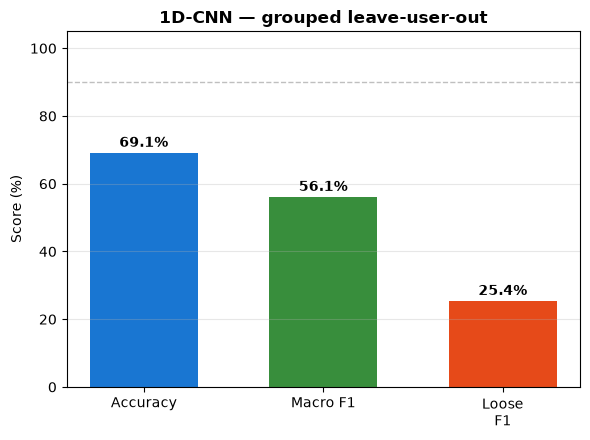

In [12]:
# ===== 1D-CNN grouped-CV results (this notebook trains only the CNN) =====
# The v21 notebook compared CNN vs XGBoost side by side in one file; here each model lives in
# its OWN notebook, so we report the CNN's grouped leave-user-out metrics. To compare against the
# other five models, collect each notebook's macro-F1 into one table (all use the same protocol).
print(f'{"1D-CNN (grouped leave-user-out)":32s}')
print(f'  {FOCUS_CLASS.capitalize()+" F1":<12s} {f1_seq[focus_idx]*100:5.1f}%')
print(f'  {"Macro F1":<12s} {mf1_seq*100:5.1f}%')
print(f'  {"Accuracy":<12s} {acc_seq*100:5.1f}%')
print(f'  per-class F1: ' + '  '.join(f'{c} {v*100:.1f}%' for c,v in zip(classes, f1_seq)))

import matplotlib.pyplot as plt
fig_s, ax = plt.subplots(figsize=(6, 4.5))
vals=[acc_seq*100, mf1_seq*100, f1_seq[focus_idx]*100]
bars=ax.bar(['Accuracy','Macro F1', f'{FOCUS_CLASS.capitalize()}\nF1'], vals,
            color=['#1976D2','#388E3C','#E64A19'], width=0.6)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,105); ax.axhline(90,color='gray',ls='--',lw=1,alpha=0.5)
ax.set_ylabel('Score (%)'); ax.set_title('1D-CNN — grouped leave-user-out', fontweight='bold'); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()


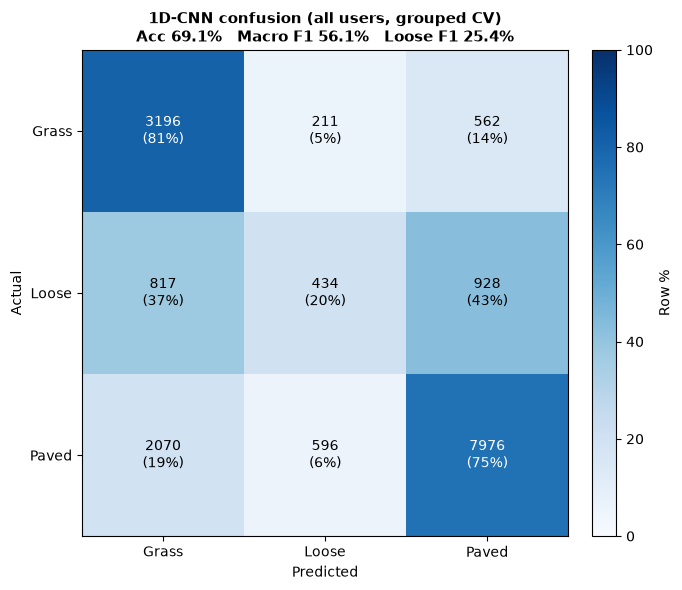

CNN per-class (grouped CV):
  grass   recall  80.5%   precision  52.5%   (n=3969)
  loose   recall  19.9%   precision  35.0%   (n=2179)
  paved   recall  74.9%   precision  84.3%   (n=10642)


In [13]:
# 1D-CNN confusion matrix — heatmap (rows = actual, annotated with count + row %)
from sklearn.metrics import confusion_matrix

_cm  = confusion_matrix(seq_true, seq_lbl, labels=classes)
_row = _cm.sum(axis=1, keepdims=True)
_pct = np.divide(_cm, _row, where=_row != 0, out=np.zeros_like(_cm, dtype=float)) * 100

fig_cm, axcm = plt.subplots(figsize=(1.7*len(classes)+2, 1.5*len(classes)+1.5))
im = axcm.imshow(_pct, cmap='Blues', vmin=0, vmax=100)
axcm.set_xticks(range(len(classes))); axcm.set_xticklabels([c.capitalize() for c in classes])
axcm.set_yticks(range(len(classes))); axcm.set_yticklabels([c.capitalize() for c in classes])
axcm.set_xlabel('Predicted'); axcm.set_ylabel('Actual')
axcm.set_title(f'1D-CNN confusion (all users, grouped CV)\n'
               f'Acc {acc_seq*100:.1f}%   Macro F1 {mf1_seq*100:.1f}%   '
               f'{FOCUS_CLASS.capitalize()} F1 {f1_seq[focus_idx]*100:.1f}%',
               fontweight='bold', fontsize=11)
for i in range(len(classes)):
    for j in range(len(classes)):
        axcm.text(j, i, f'{_cm[i, j]}\n({_pct[i, j]:.0f}%)', ha='center', va='center',
                  color='white' if _pct[i, j] > 55 else 'black', fontsize=10)
cbar = fig_cm.colorbar(im, ax=axcm, fraction=0.046, pad=0.04); cbar.set_label('Row %')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'cnn_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()

print('CNN per-class (grouped CV):')
for i, cl in enumerate(classes):
    rec = _cm[i, i] / _row[i, 0] * 100 if _row[i, 0] else float('nan')
    col = _cm[:, i].sum(); prec = _cm[i, i] / col * 100 if col else float('nan')
    print(f'  {cl:6s}  recall {rec:5.1f}%   precision {prec:5.1f}%   (n={int(_row[i,0])})')